In [16]:

!pip install scikit-learn --quiet

In [17]:

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import time
import matplotlib.pyplot as plt
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cpu


In [18]:

N = 30000
Nr = 4
Nt = 8
SNR_dB = 10
MODE = "datadriven" #or "sicnet"
EPOCHS = 40
BATCH = 256
LR = 1e-3




In [19]:
def qpsk_mod(bits):
    mapping = np.array([1+1j, 1-1j, -1-1j, -1+1j])
    idx = bits[:,0] * 2 + bits[:,1]
    return mapping[idx]

def qpsk_demod(symbols):
    const = np.array([1+1j, 1-1j, -1-1j, -1+1j])
    d = np.abs(symbols[:,:,None] - const[None,None,:])
    return np.argmin(d, axis=-1)  # (N, Nt)

def complex_to_real_flat(x):
    return np.concatenate([x.real.reshape(x.shape[0], -1),
                           x.imag.reshape(x.shape[0], -1)], axis=-1)

def mmse_init(H, Y, reg=1e-2):
    N = H.shape[0]
    Nt = H.shape[2]
    s_hat = np.zeros((N, Nt), dtype=np.complex128)
    for i in range(N):
        Hi = H[i]
        yi = Y[i]
        HhH = Hi.conj().T @ Hi
        inv = np.linalg.pinv(HhH + reg*np.eye(Nt))
        s_hat[i] = inv @ (Hi.conj().T @ yi)
    return complex_to_real_flat(s_hat)

def normalize_rows(a):
    n = np.linalg.norm(a, axis=1, keepdims=True)
    n[n==0] = 1
    return a / n




In [20]:
print("Generating synthetic Rayleigh MIMO data...")

H = (np.random.randn(N, Nr, Nt) + 1j*np.random.randn(N, Nr, Nt)) / np.sqrt(2)
bits = np.random.randint(0, 2, size=(N, Nt, 2))
X = qpsk_mod(bits.reshape(N*Nt, 2)).reshape(N, Nt)

SNR = 10**(SNR_dB/10)
noise_var = Nt / SNR  # standard normalization

noise = np.sqrt(noise_var/2)*(np.random.randn(N, Nr)+1j*np.random.randn(N, Nr))
Y = H @ X[...,None]   # (N, Nr, 1)
Y = Y.squeeze(-1) + noise

labels = qpsk_demod(X)

Y_feat = complex_to_real_flat(Y)
H_feat = complex_to_real_flat(H)
s_mmse = mmse_init(H, Y)
inputs = np.hstack([Y_feat, H_feat, s_mmse])
inputs = normalize_rows(inputs)

input_dim = inputs.shape[1]



Generating synthetic Rayleigh MIMO data...


In [21]:

x_tr, x_te, y_tr, y_te = train_test_split(inputs, labels, test_size=0.2, random_state=42)

train_feats = torch.tensor(x_tr, dtype=torch.float32).to(DEVICE)
train_labels = torch.tensor(y_tr, dtype=torch.long).to(DEVICE)
train_H = torch.tensor(H[np.arange(len(x_tr))], dtype=torch.complex64).to(DEVICE)
train_Y = torch.tensor(Y[np.arange(len(x_tr))], dtype=torch.complex64).to(DEVICE)

test_feats = torch.tensor(x_te, dtype=torch.float32).to(DEVICE)
test_labels = torch.tensor(y_te, dtype=torch.long).to(DEVICE)
test_H = torch.tensor(H[-len(x_te):], dtype=torch.complex64).to(DEVICE)
test_Y = torch.tensor(Y[-len(x_te):], dtype=torch.complex64).to(DEVICE)


CLASS_TO_BITS = torch.tensor([[0,0],[0,1],[1,1],[1,0]], dtype=torch.uint8).to(DEVICE)

def compute_ber(pred_idx, true_idx):
    pred_bits = CLASS_TO_BITS[pred_idx]
    true_bits = CLASS_TO_BITS[true_idx]
    return ((pred_bits != true_bits).sum().item(), pred_bits.numel())


In [22]:

class DNNDetector(nn.Module):
    def __init__(self, input_dim, Nt):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, Nt*4)
        )
        self.Nt = Nt
    def forward(self, x):
        out = self.model(x).view(-1, self.Nt, 4)
        return out

class SICNet(nn.Module):
    def __init__(self, Nr, Nt, input_dim, iterations=6):
        super().__init__()
        self.init_fc = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, Nt*4)
        )
        self.Nr, self.Nt = Nr, Nt
        self.const = torch.tensor([1+1j,1-1j,-1-1j,-1+1j]).to(DEVICE)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(2, 16), nn.ReLU(),
                nn.Linear(16,4)
            ) for _ in range(iterations)
        ])
        self.tau = nn.Parameter(torch.ones(iterations)*0.5)
        self.iter = iterations

    def forward(self, feats, H, Y):
        B = feats.shape[0]
        logits = self.init_fc(feats).view(B, self.Nt, 4)
        for k in range(self.iter):
            probs = torch.softmax(logits, dim=-1)
            s_exp = (probs.to(torch.complex64) @ self.const)

            inter = torch.einsum("brt,bt->br", H, s_exp)
            Y_expanded = Y.unsqueeze(-1)  # (B, Nr, 1)
            y_eff = Y_expanded - inter.unsqueeze(-1) + H * s_exp.unsqueeze(1)
            z = torch.einsum("brt,brt->bt", H.conj(), y_eff)
            z_realimag = torch.stack([z.real, z.imag], dim=-1)
            logits_new = self.blocks[k](z_realimag.view(B*self.Nt,2)).view(B,self.Nt,4)

            logits = self.tau[k]*logits_new + (1-self.tau[k])*logits
        return logits



In [23]:

model = DNNDetector(input_dim, Nt).to(DEVICE) if MODE=="datadriven" else SICNet(Nr,Nt,input_dim).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

print("Training", MODE, "detector ...")

train_size = len(train_feats)
test_size = len(test_feats)
loss_history = []
ber_history = []
for epoch in range(1, EPOCHS+1):
    model.train()
    perm = np.random.permutation(train_size)
    loss_epoch = 0
    for i in range(0, train_size, BATCH):
        idx = perm[i:i+BATCH]
        xb = train_feats[idx]
        yb = train_labels[idx]
        Hb = train_H[idx]
        Yb = train_Y[idx]

        logits = model(xb, Hb, Yb) if MODE=="sicnet" else model(xb)
        loss = criterion(logits.view(-1,4), yb.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_epoch += loss.item()*len(idx)

    loss_epoch /= train_size

    # Evaluation
    model.eval()
    tot_err=tot_bits=0
    with torch.no_grad():
        for i in range(0, test_size, BATCH):
            idx = np.arange(i, min(i+BATCH,test_size))
            xb = test_feats[idx]
            yb = test_labels[idx]
            Hb = test_H[idx]
            Yb = test_Y[idx]
            preds = torch.argmax(model(xb,Hb,Yb) if MODE=="sicnet" else model(xb), dim=-1)
            err,bits = compute_ber(preds, yb)
            tot_err+=err
            tot_bits+=bits
    ber = tot_err/tot_bits
    loss_history.append(loss_epoch)
    ber_history.append(ber)
    print(f"Epoch {epoch:02d} | Loss {loss_epoch:.4f} | BER={ber:.6f}")

print("Training complete.")


Training datadriven detector ...
Epoch 01 | Loss 1.3201 | BER=0.257937
Epoch 02 | Loss 0.9431 | BER=0.195417
Epoch 03 | Loss 0.8251 | BER=0.192250
Epoch 04 | Loss 0.8188 | BER=0.192594
Epoch 05 | Loss 0.8165 | BER=0.191010
Epoch 06 | Loss 0.8144 | BER=0.191427
Epoch 07 | Loss 0.8127 | BER=0.191771
Epoch 08 | Loss 0.8120 | BER=0.191646
Epoch 09 | Loss 0.8102 | BER=0.191302
Epoch 10 | Loss 0.8090 | BER=0.191552
Epoch 11 | Loss 0.8081 | BER=0.191031
Epoch 12 | Loss 0.8064 | BER=0.191156
Epoch 13 | Loss 0.8057 | BER=0.191417
Epoch 14 | Loss 0.8040 | BER=0.192281
Epoch 15 | Loss 0.8030 | BER=0.191479
Epoch 16 | Loss 0.8017 | BER=0.192156
Epoch 17 | Loss 0.8006 | BER=0.190927
Epoch 18 | Loss 0.7995 | BER=0.192031
Epoch 19 | Loss 0.7983 | BER=0.192083
Epoch 20 | Loss 0.7968 | BER=0.192323
Epoch 21 | Loss 0.7951 | BER=0.192698
Epoch 22 | Loss 0.7941 | BER=0.193469
Epoch 23 | Loss 0.7928 | BER=0.192760
Epoch 24 | Loss 0.7913 | BER=0.192906
Epoch 25 | Loss 0.7898 | BER=0.193125
Epoch 26 | Loss 0

In [24]:

def generate_rayleigh_test(N, Nr, Nt, SNR_dB):
    H = (np.random.randn(N, Nr, Nt) + 1j*np.random.randn(N, Nr, Nt)) / np.sqrt(2)
    bits = np.random.randint(0, 2, size=(N, Nt, 2))
    mapping = np.array([1+1j, 1-1j, -1-1j, -1+1j])
    idx = bits[:,:,0]*2 + bits[:,:,1]
    X = mapping[idx]

    SNR = 10**(SNR_dB/10)
    noise_var = Nt/SNR
    noise = np.sqrt(noise_var/2)*(np.random.randn(N,Nr)+1j*np.random.randn(N,Nr))

    Y = (H @ X[...,None]).squeeze(-1) + noise
    labels = qpsk_demod(X)

    Y_feat = complex_to_real_flat(Y)
    H_feat = complex_to_real_flat(H)
    s_mmse = mmse_init(H, Y)
    feats = normalize_rows(np.hstack([Y_feat, H_feat, s_mmse]))

    return (
        torch.tensor(feats, dtype=torch.float32).to(DEVICE),
        torch.tensor(labels, dtype=torch.long).to(DEVICE),
        torch.tensor(H, dtype=torch.complex64).to(DEVICE),
        torch.tensor(Y, dtype=torch.complex64).to(DEVICE),
    )

def test_ber(model, feats, labels, H, Y):
    model.eval()
    with torch.no_grad():
        logits = model(feats, H, Y) if MODE=="sicnet" else model(feats)
        preds = torch.argmax(logits, dim=-1)
        err, bits = compute_ber(preds, labels)
        return err/bits

SNRs = [0, 5, 10, 15, 20]
BERs = []



Running SNR sweep...
SNR 0 dB → BER = 0.28308
SNR 5 dB → BER = 0.22440
SNR 10 dB → BER = 0.19700
SNR 15 dB → BER = 0.18056
SNR 20 dB → BER = 0.18101


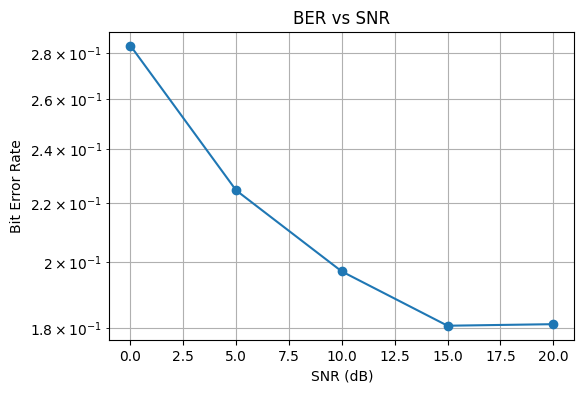

In [25]:
print("Running SNR sweep...")
for snr in SNRs:
    feats, labels, Ht, Yt = generate_rayleigh_test(5000, Nr, Nt, snr)
    ber = test_ber(model, feats, labels, Ht, Yt)
    BERs.append(ber)
    print(f"SNR {snr} dB → BER = {ber:.5f}")

plt.figure(figsize=(6,4))
plt.semilogy(SNRs, BERs, marker='o')
plt.grid(True, which='both')
plt.title("BER vs SNR")
plt.ylabel("Bit Error Rate")
plt.xlabel("SNR (dB)")
plt.show()




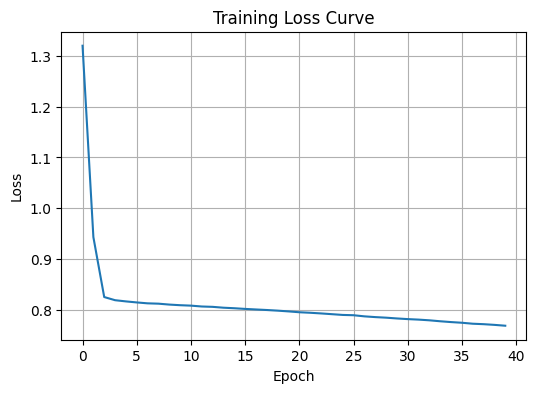

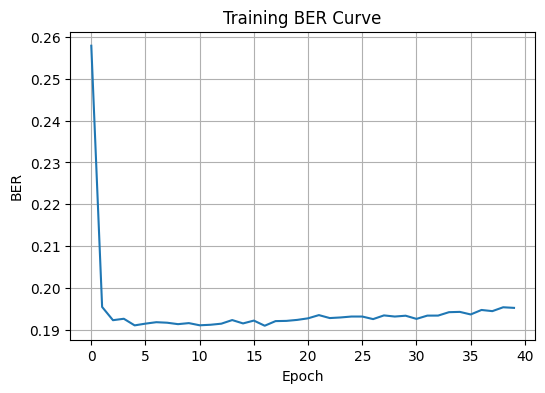

In [26]:


if "loss_history" in globals() and "ber_history" in globals():
    plt.figure(figsize=(6,4))
    plt.plot(loss_history, label="Loss")
    plt.grid(True)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(ber_history, label="Validation BER")
    plt.grid(True)
    plt.xlabel("Epoch")
    plt.ylabel("BER")
    plt.title("Training BER Curve")
    plt.show()
else:
    print("Training curves not available: make sure you record loss_history[] and ber_history[] during training.")
